# DART40 F20TR vs WCYCL20TR observation-diagnostic comparison

## Purpose

This notebook validates and compares the DART observation-space diagnostics produced by the **F20TR** and **WCYCL20TR** DART40 experiments. It is intended to determine whether the two experiments produce equivalent prior (`guess`) observation diagnostics over their shared coordinates and times, and to show where their forecast error, ensemble calibration, or observation-use behavior differs.

## Inputs

The configuration cell constructs one `eam_obs_diag_output` NetCDF path for each experiment from `DATA_ROOT`, the case name, and the diagnostic period. `DATA_ROOT` is derived from the top-level `INPUT_DATA_ROOT` notebook parameter. Both input files must already exist; the notebook does not generate DART diagnostics.

## Numerical comparison

`compare_overlapping_diagnostics()` finds data variables present in both files whose names end in `_guess`, `_VPguess`, or `_guess_RankHist`. It aligns each pair using the intersection of their labeled coordinates, compares values with `numpy.isclose` using the configured `RTOL` and `ATOL` tolerances, and treats matching missing values as equal. The resulting table reports the overlap shape, number of values outside tolerance, maximum absolute difference, and mean absolute difference for every compared variable. The table is sorted so the largest disagreements appear first.

## Time-series plots

For the selected region and pressure layers, the notebook compares radiosonde zonal wind (U), meridional wind (V), temperature (T), and specific humidity (Q). It extracts three metrics from each variable's prior diagnostic array:

- **RMSE:** root-mean-square error of the prior ensemble mean relative to the observations.
- **Spread / RMSE:** total prior ensemble spread divided by RMSE; values near one indicate that ensemble dispersion and observed error are similar in magnitude.
- **Rejection (%):** `100 - 100 * Nused / Nposs`, the percentage of potentially available observations not used by the diagnostic.

Only times present in both files are plotted. The horizontal axis is days since the first common time and is restricted by `XMIN` and `XMAX`. A panel labeled `No valid observations` indicates that the selected variable, region, pressure layer, and time window contain no finite diagnostic values.

## Configuration and outputs

Edit `CASE_RUNS`, `REGION`, `PLOT_VARIABLES`, `PLOT_LEVELS`, `XMIN`, `XMAX`, `RTOL`, and `ATOL` in the configuration cell to change the comparison. `SHOW` controls interactive display and `SAVE` controls PDF output. When saving is enabled, the notebook writes one 3-by-4 comparison figure per selected pressure layer to `FIGURE_DIR`; it does not modify the input NetCDF files. Run the notebook from top to bottom after changing any configuration value.


In [1]:
# =============================================================================
# TOP-LEVEL PATH PARAMETERS
# Edit these three paths to relocate inputs, the analysis checkout, or outputs.
# =============================================================================
from pathlib import Path
import os
import sys

INPUT_DATA_ROOT = Path("/compyfs/zhan391/v3_dart_cda_scratch")
WORK_DIR = Path("/compyfs/zhan391/work_package/e3sm_dart_analysis")
DIAGNOSTIC_OUTPUT_ROOT = Path("/compyfs/www/zhan391/e3sm_dart/diag_dart_2026")
WORKFLOW_NAME = "analysis_atm_da"

In [2]:
# Derived paths: built from the parameters above.
import sys
from pathlib import Path

DIAGNOSTIC_DIR = WORK_DIR / "diagnostic"
if not DIAGNOSTIC_DIR.is_dir():
    raise FileNotFoundError(f"Diagnostic work directory not found: {DIAGNOSTIC_DIR}")
if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

from configs.output_paths import workflow_output_dirs
WORKFLOW_DATA_DIR, WORKFLOW_FIGURE_DIR = workflow_output_dirs(
    WORKFLOW_NAME,
    output_root=DIAGNOSTIC_OUTPUT_ROOT,
)

In [3]:
import os
from pathlib import Path
import sys

CWD = WORK_DIR
DIAGNOSTIC_DIR = WORK_DIR / "diagnostic"
if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

from configs.output_paths import workflow_output_dirs
ANALYSIS_DATA_DIR, ANALYSIS_FIGURE_DIR = workflow_output_dirs("analysis_atm_da", output_root=DIAGNOSTIC_OUTPUT_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [4]:
DATA_ROOT = INPUT_DATA_ROOT
CASE_RUNS = {
    "F20TR": {
        "run_name": "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "diag_period": "2011120100-2012010100",
    },
    "WCYCL20TR": {
        "run_name": "DARTEN40_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "diag_period": "2011120100-2012010100",
    },
}

REGION = "Northern Hemisphere"
XMIN, XMAX = 0, 30
RTOL, ATOL = 1e-7, 0.0

PLOT_VARIABLES = [
    "RADIOSONDE_U_WIND_COMPONENT",
    "RADIOSONDE_V_WIND_COMPONENT",
    "RADIOSONDE_TEMPERATURE",
    "RADIOSONDE_SPECIFIC_HUMIDITY",
]
# choices are ['962-1035 hPa', '887-962 hPa', '775-887 hPa', '600-775 hPa', 
#              '450-600 hPa', '350-450 hPa', '275-350 hPa', '225-275 hPa', 
#              '175-225 hPa', '125-175 hPa', '75-125 hPa', '35-75 hPa', 
#              '15-35 hPa', '2-15 hPa']
PLOT_LEVELS = ["962-1035 hPa", '775-887 hPa', "450-600 hPa", "225-275 hPa"]

SHOW = True
SAVE = True
FIGURE_DIR = ANALYSIS_FIGURE_DIR / "obs_diag_check"


In [5]:
def _diag_file(case):
    run_name = case["run_name"]
    diag_dir = (
        DATA_ROOT / run_name
        / "dart_en40/eam/dart_diagnostics/obs_diag"
    )
    return diag_dir / (
        f"{run_name}.dart.e.eam_obs_diag_output."
        f"{case['diag_period']}.nc"
    )


DIAG_FILES = {
    label: _diag_file(case)
    for label, case in CASE_RUNS.items()
}
for label, file_path in DIAG_FILES.items():
    print(f"{label}: {file_path}")


F20TR: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/dart_en40/eam/dart_diagnostics/obs_diag/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc
WCYCL20TR: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_compy/dart_en40/eam/dart_diagnostics/obs_diag/DARTEN40_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011120100-2012010100.nc


In [6]:
def _check_files():
    for file_path in DIAG_FILES.values():
        if not file_path.is_file():
            raise FileNotFoundError(file_path)


def _strings(values):
    values = np.asarray(values)
    return [
        value.decode("utf-8").strip()
        if isinstance(value, (bytes, np.bytes_))
        else str(value).strip()
        for value in values
    ]


def compare_overlapping_diagnostics(rtol=RTOL, atol=ATOL):
    # Compare every shared diagnostic array on coordinates present in both files.
    _check_files()
    rows = []

    reference_label, comparison_label = DIAG_FILES
    with xr.open_dataset(
        DIAG_FILES[reference_label], decode_times=False
    ) as reference, xr.open_dataset(
        DIAG_FILES[comparison_label], decode_times=False
    ) as comparison:
        names = sorted(
            name
            for name in set(reference.data_vars).intersection(comparison.data_vars)
            if name.endswith(("_guess", "_VPguess", "_guess_RankHist"))
        )

        for name in names:
            reference_data, comparison_data = xr.align(
                reference[name], comparison[name], join="inner"
            )
            reference_values = np.asarray(reference_data.values)
            comparison_values = np.asarray(comparison_data.values)
            close = np.isclose(
                reference_values,
                comparison_values,
                rtol=rtol,
                atol=atol,
                equal_nan=True,
            )
            difference = np.abs(reference_values - comparison_values)
            finite = difference[np.isfinite(difference)]

            rows.append({
                "variable": name,
                "overlap_shape": reference_values.shape,
                "different_values": int(close.size - np.count_nonzero(close)),
                "max_abs_difference": (
                    float(finite.max()) if finite.size else np.nan
                ),
                "mean_abs_difference": (
                    float(finite.mean()) if finite.size else np.nan
                ),
            })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["different_values", "max_abs_difference"],
            ascending=False,
        )
        .reset_index(drop=True)
    )


In [7]:
difference_summary = compare_overlapping_diagnostics()
display(difference_summary)


/qfs/people/zhan391/.conda/envs/e3sm_analysis/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


,variable,overlap_shape,different_values,max_abs_difference,mean_abs_difference
0,GPSRO_REFRACTIVITY_guess_RankHist,"(125, 41, 14, 5)",306797,928.0,5.912000
1,AIRS_TEMPERATURE_guess_RankHist,"(125, 41, 14, 5)",263455,76.0,2.635097
2,RADIOSONDE_V_WIND_COMPONENT_guess_RankHist,"(125, 41, 14, 5)",258455,94.0,2.751286
3,RADIOSONDE_U_WIND_COMPONENT_guess_RankHist,"(125, 41, 14, 5)",257570,158.0,2.842626
4,RADIOSONDE_TEMPERATURE_guess_RankHist,"(125, 41, 14, 5)",226260,87.0,2.440552
...,...,...,...,...,...
56,MARINE_SFC_SPECIFIC_HUMIDITY_guess,"(125, 23, 1, 5)",0,0.0,0.000000
57,MARINE_SFC_TEMPERATURE_guess,"(125, 23, 1, 5)",0,0.0,0.000000
58,MARINE_SFC_U_WIND_COMPONENT_guess,"(125, 23, 1, 5)",0,0.0,0.000000
59,MARINE_SFC_V_WIND_COMPONENT_guess,"(125, 23, 1, 5)",0,0.0,0.000000


In [8]:
def _pressure_labels(ds):
    edges = np.asarray(ds["plevel_edges"].values)
    return [
        f"{int(edges[index + 1])}-{int(edges[index])} hPa"
        for index in range(ds.sizes["plevel"])
    ]


def _metric_series(ds, variable, region_index, level_index):
    copies = {
        name: index
        for index, name in enumerate(_strings(ds["CopyMetaData"].values))
    }
    data = ds[f"{variable}_guess"].isel(
        region=region_index,
        plevel=level_index,
    )

    rmse = data.isel(copy=copies["rmse"])
    spread = data.isel(copy=copies["totalspread"])
    nposs = data.isel(copy=copies["Nposs"])
    nused = data.isel(copy=copies["Nused"])

    return {
        "RMSE": rmse,
        "Spread / RMSE": xr.where(rmse != 0, spread / rmse, np.nan),
        "Rejection (%)": xr.where(
            nposs > 0,
            100.0 - 100.0 * nused / nposs,
            np.nan,
        ),
    }


def plot_level_comparison(level_label, show=SHOW, save=SAVE):
    _check_files()
    datasets = {
        label: xr.open_dataset(file_path, decode_times=False)
        for label, file_path in DIAG_FILES.items()
    }

    try:
        metrics = {}
        for label, ds in datasets.items():
            region_names = _strings(ds["region_names"].values)
            if REGION not in region_names:
                raise ValueError(
                    f"{REGION!r} is unavailable; choices are {region_names}"
                )
            level_names = _pressure_labels(ds)
            if level_label not in level_names:
                raise ValueError(
                    f"{level_label!r} is unavailable; choices are {level_names}"
                )

            metrics[label] = {
                variable: _metric_series(
                    ds, variable, region_names.index(REGION),
                    level_names.index(level_label),
                )
                for variable in PLOT_VARIABLES
            }

        common_times = None
        for ds in datasets.values():
            times = np.asarray(ds["time"].values)
            common_times = (
                times if common_times is None
                else np.intersect1d(common_times, times)
            )
        if common_times.size == 0:
            raise ValueError("The selected diagnostics have no common times")
        time_origin = float(common_times[0])

        metric_names = list(metrics[next(iter(metrics))][PLOT_VARIABLES[0]])
        column_labels = ["U", "V", "T", "Q"]
        fig, axes = plt.subplots(
            len(metric_names), len(PLOT_VARIABLES),
            figsize=(20, 12), sharex=True, squeeze=False,
        )
        for column, (variable, column_label) in enumerate(
            zip(PLOT_VARIABLES, column_labels)
        ):
            axes[0, column].set_title(column_label)
            for row, metric_name in enumerate(metric_names):
                axis = axes[row, column]
                has_valid_data = False
                for label, ds_metrics in metrics.items():
                    values = ds_metrics[variable][metric_name]
                    times = np.asarray(values["time"].values)
                    relative_time = times - time_origin
                    mask = (
                        np.isin(times, common_times)
                        & (relative_time >= XMIN)
                        & (relative_time <= XMAX)
                    )
                    plotted_values = np.asarray(values)[mask]
                    has_valid_data |= bool(np.isfinite(plotted_values).any())
                    axis.plot(
                        relative_time[mask], plotted_values,
                        marker="o", label=label,
                    )
                if not has_valid_data:
                    axis.text(
                        0.5, 0.5, "No valid observations",
                        ha="center", va="center",
                        transform=axis.transAxes, color="0.4",
                    )
                axis.grid(alpha=0.25)
                axis.set_xlim(XMIN, XMAX)
                if column == 0:
                    axis.set_ylabel(metric_name)
                if row == len(metric_names) - 1:
                    axis.set_xlabel("Days since common start")

        axes[0, 0].legend()
        fig.suptitle(f"{level_label} | {REGION}", fontsize=16)
        fig.tight_layout(rect=(0, 0, 1, 0.97))

        if save:
            FIGURE_DIR.mkdir(parents=True, exist_ok=True)
            output = FIGURE_DIR / f"UVTQ_{level_label.replace(' ', '')}.pdf"
            fig.savefig(output, dpi=300, bbox_inches="tight")
            print(f"Saved {output}")
        if show:
            plt.show()
        else:
            plt.close(fig)
    finally:
        for ds in datasets.values():
            ds.close()


Saved /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/figure/analysis_atm_da/obs_diag_check/UVTQ_962-1035hPa.pdf


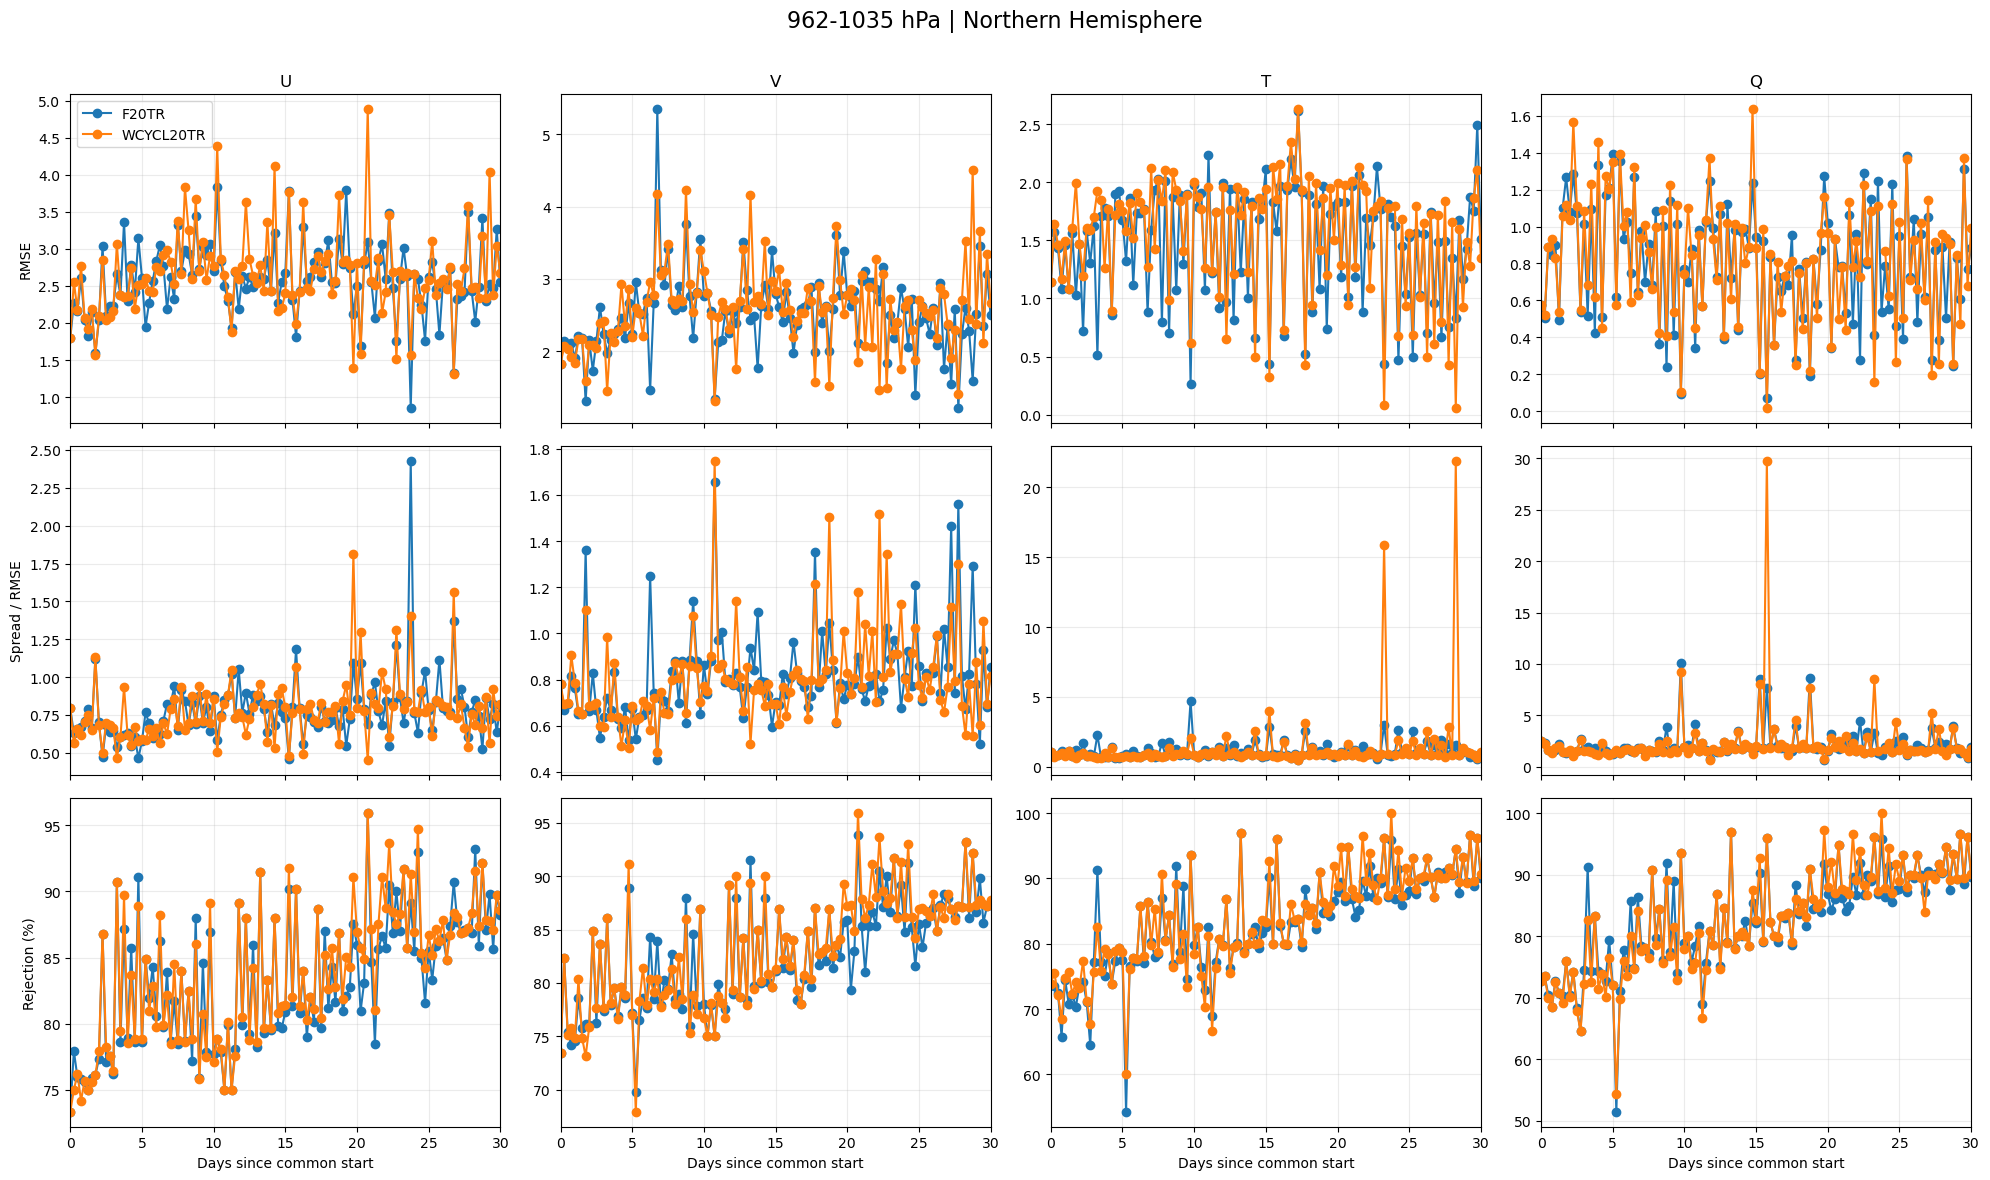

Saved /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/figure/analysis_atm_da/obs_diag_check/UVTQ_775-887hPa.pdf


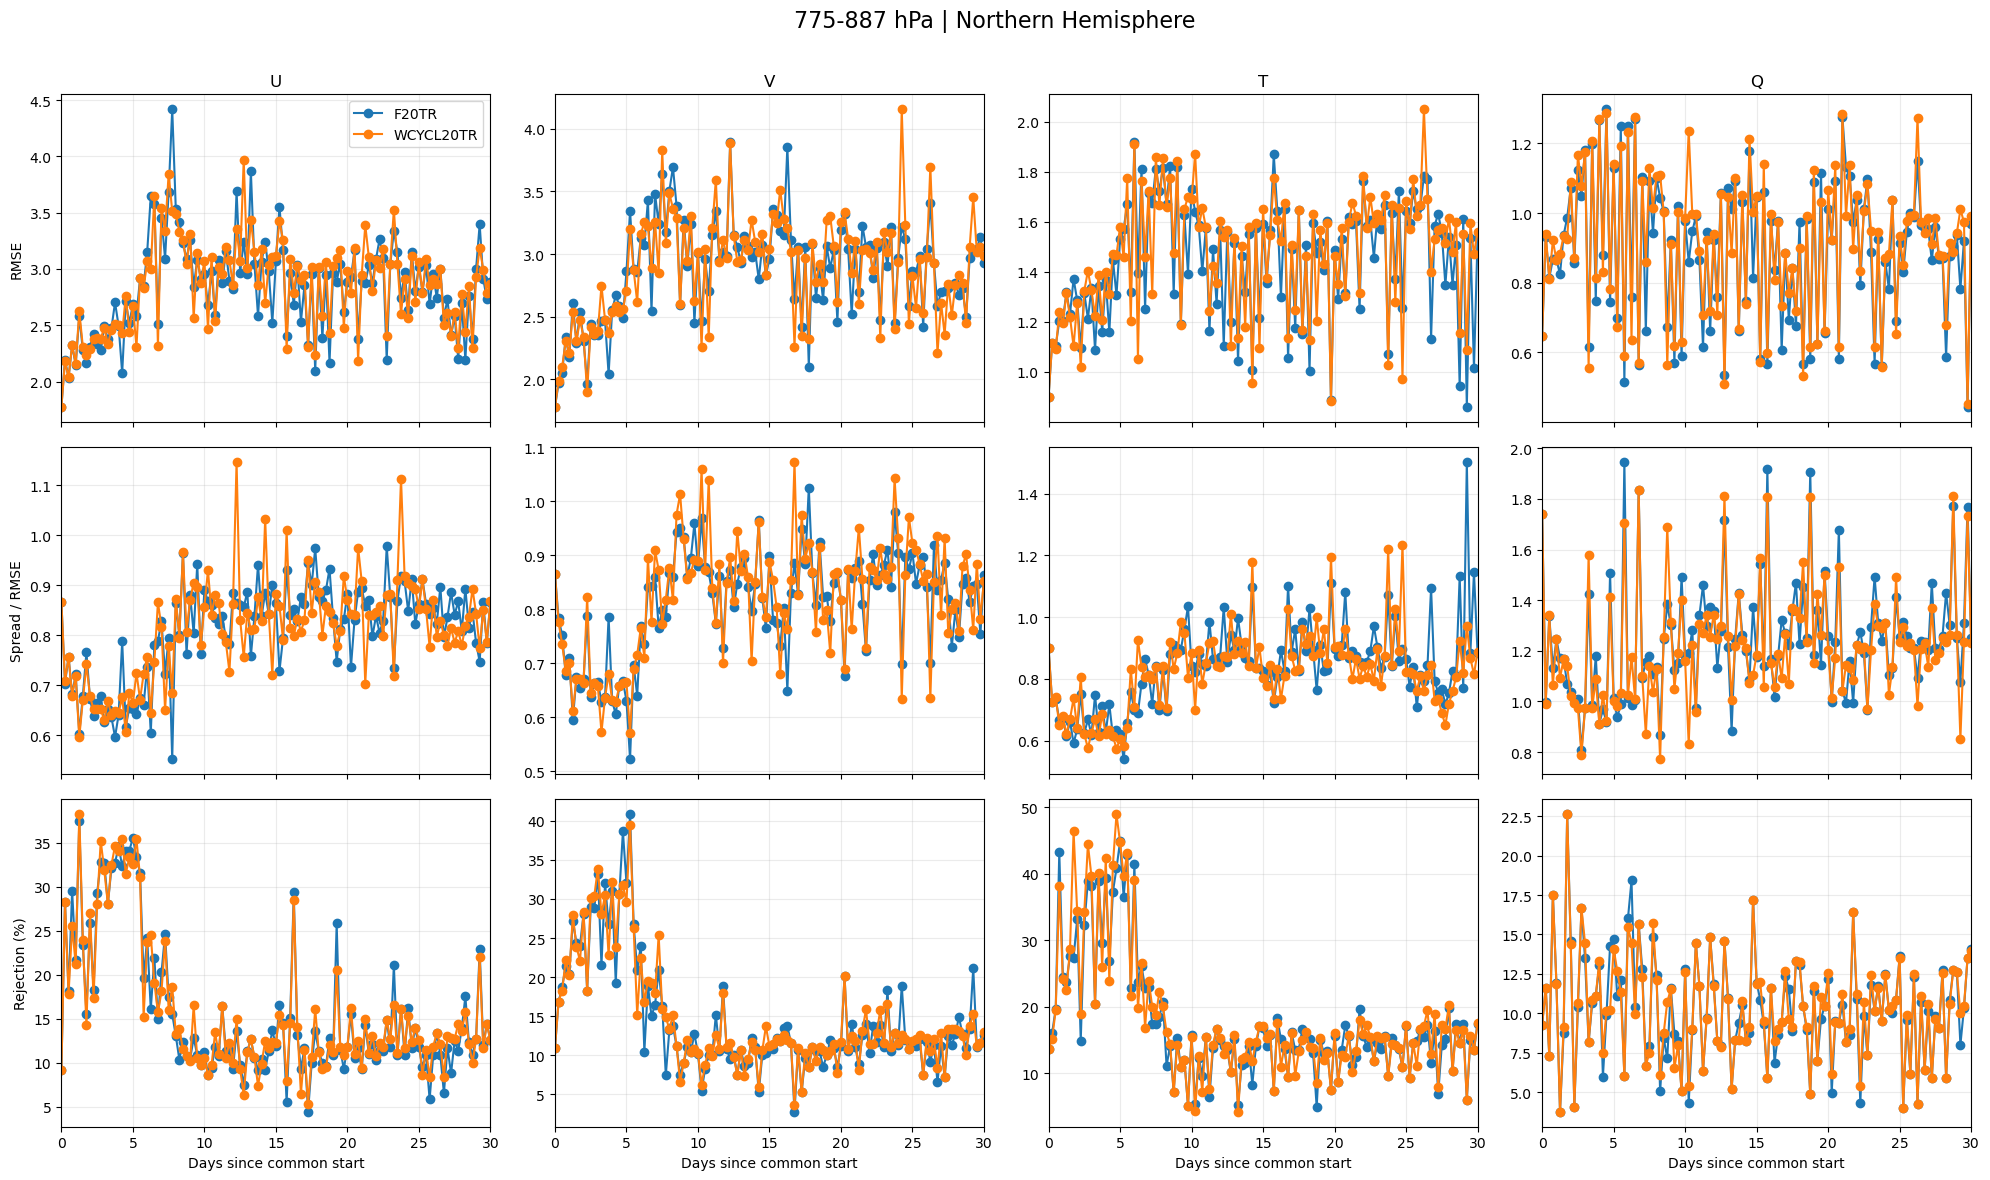

Saved /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/figure/analysis_atm_da/obs_diag_check/UVTQ_450-600hPa.pdf


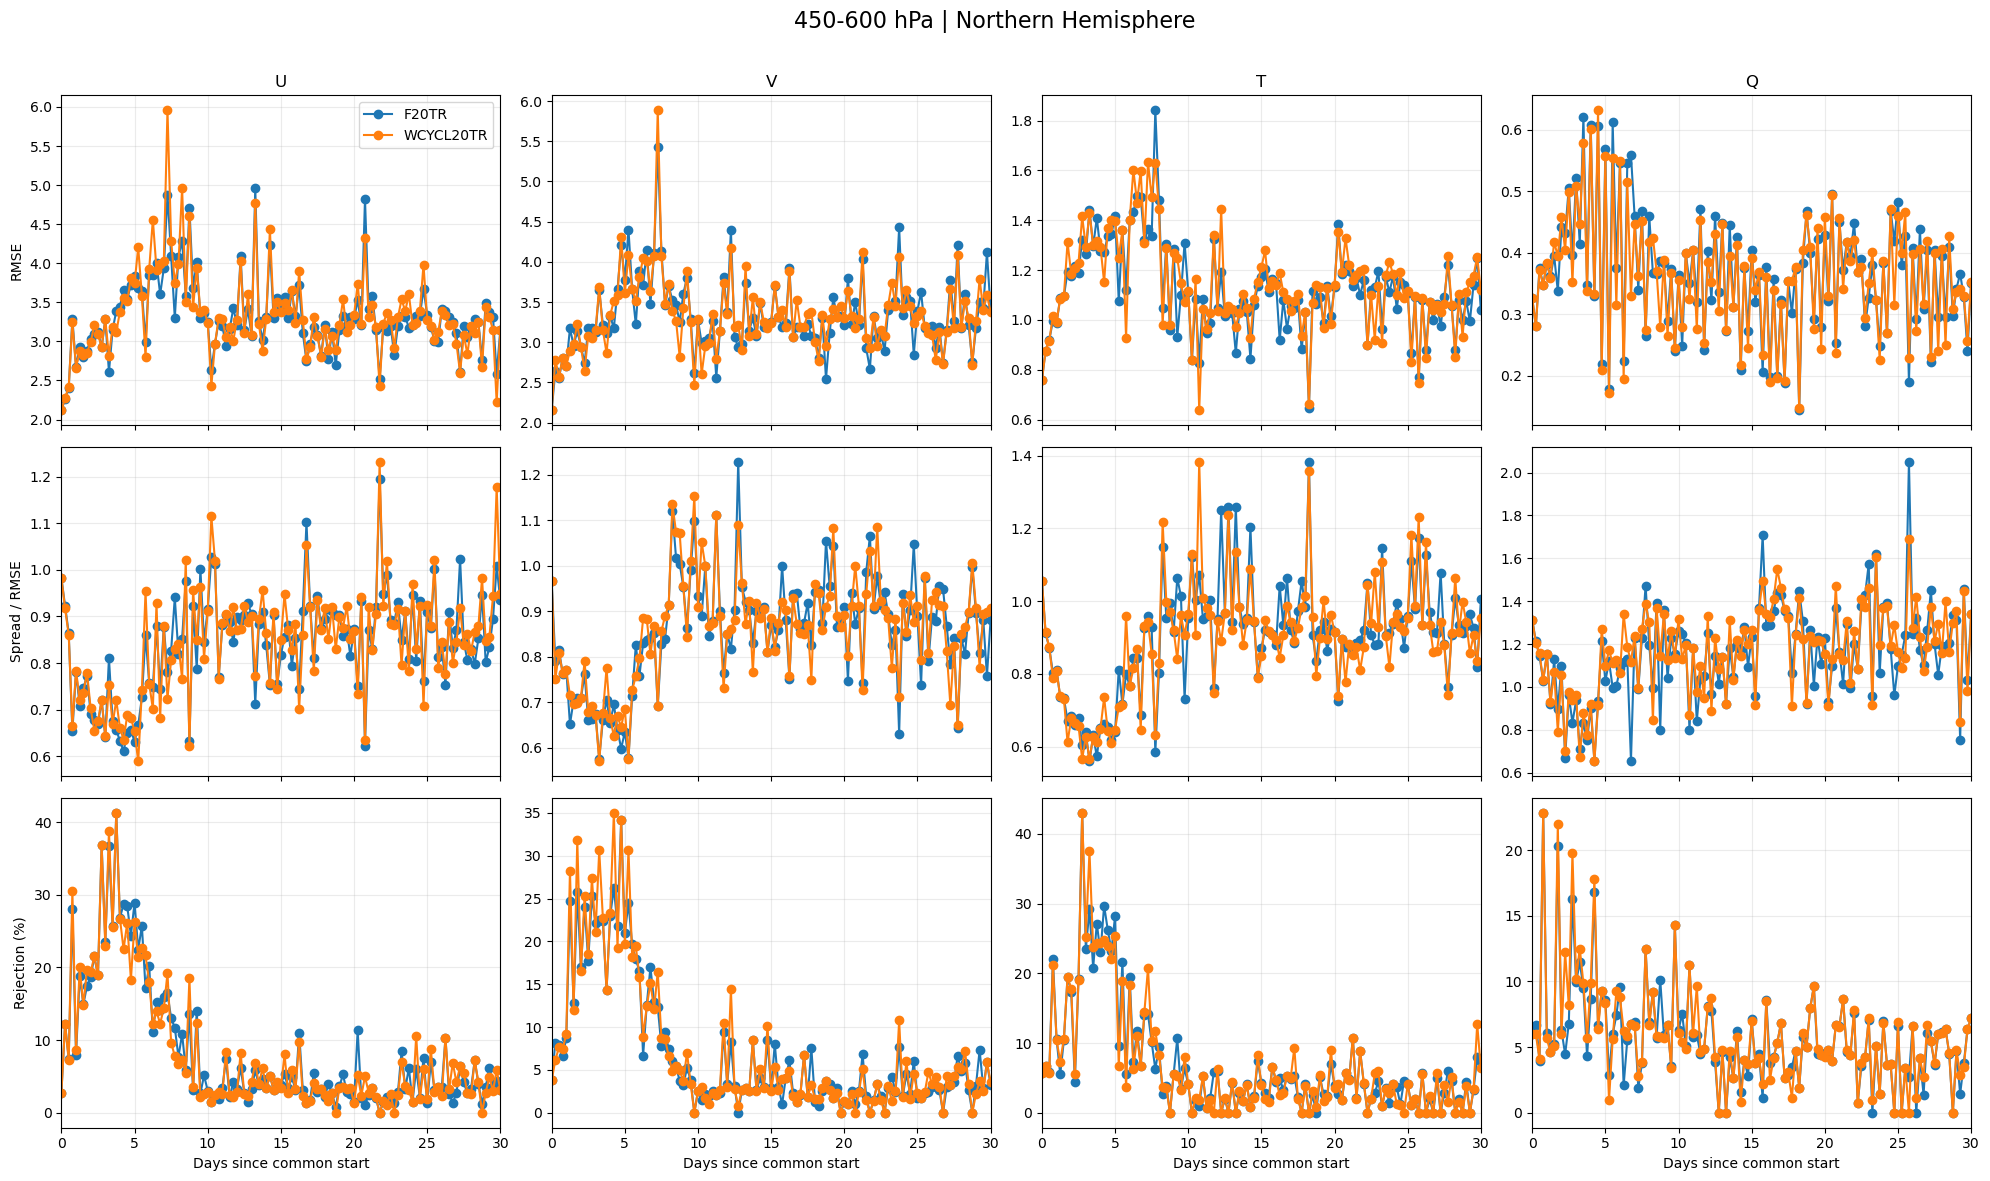

Saved /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/figure/analysis_atm_da/obs_diag_check/UVTQ_225-275hPa.pdf


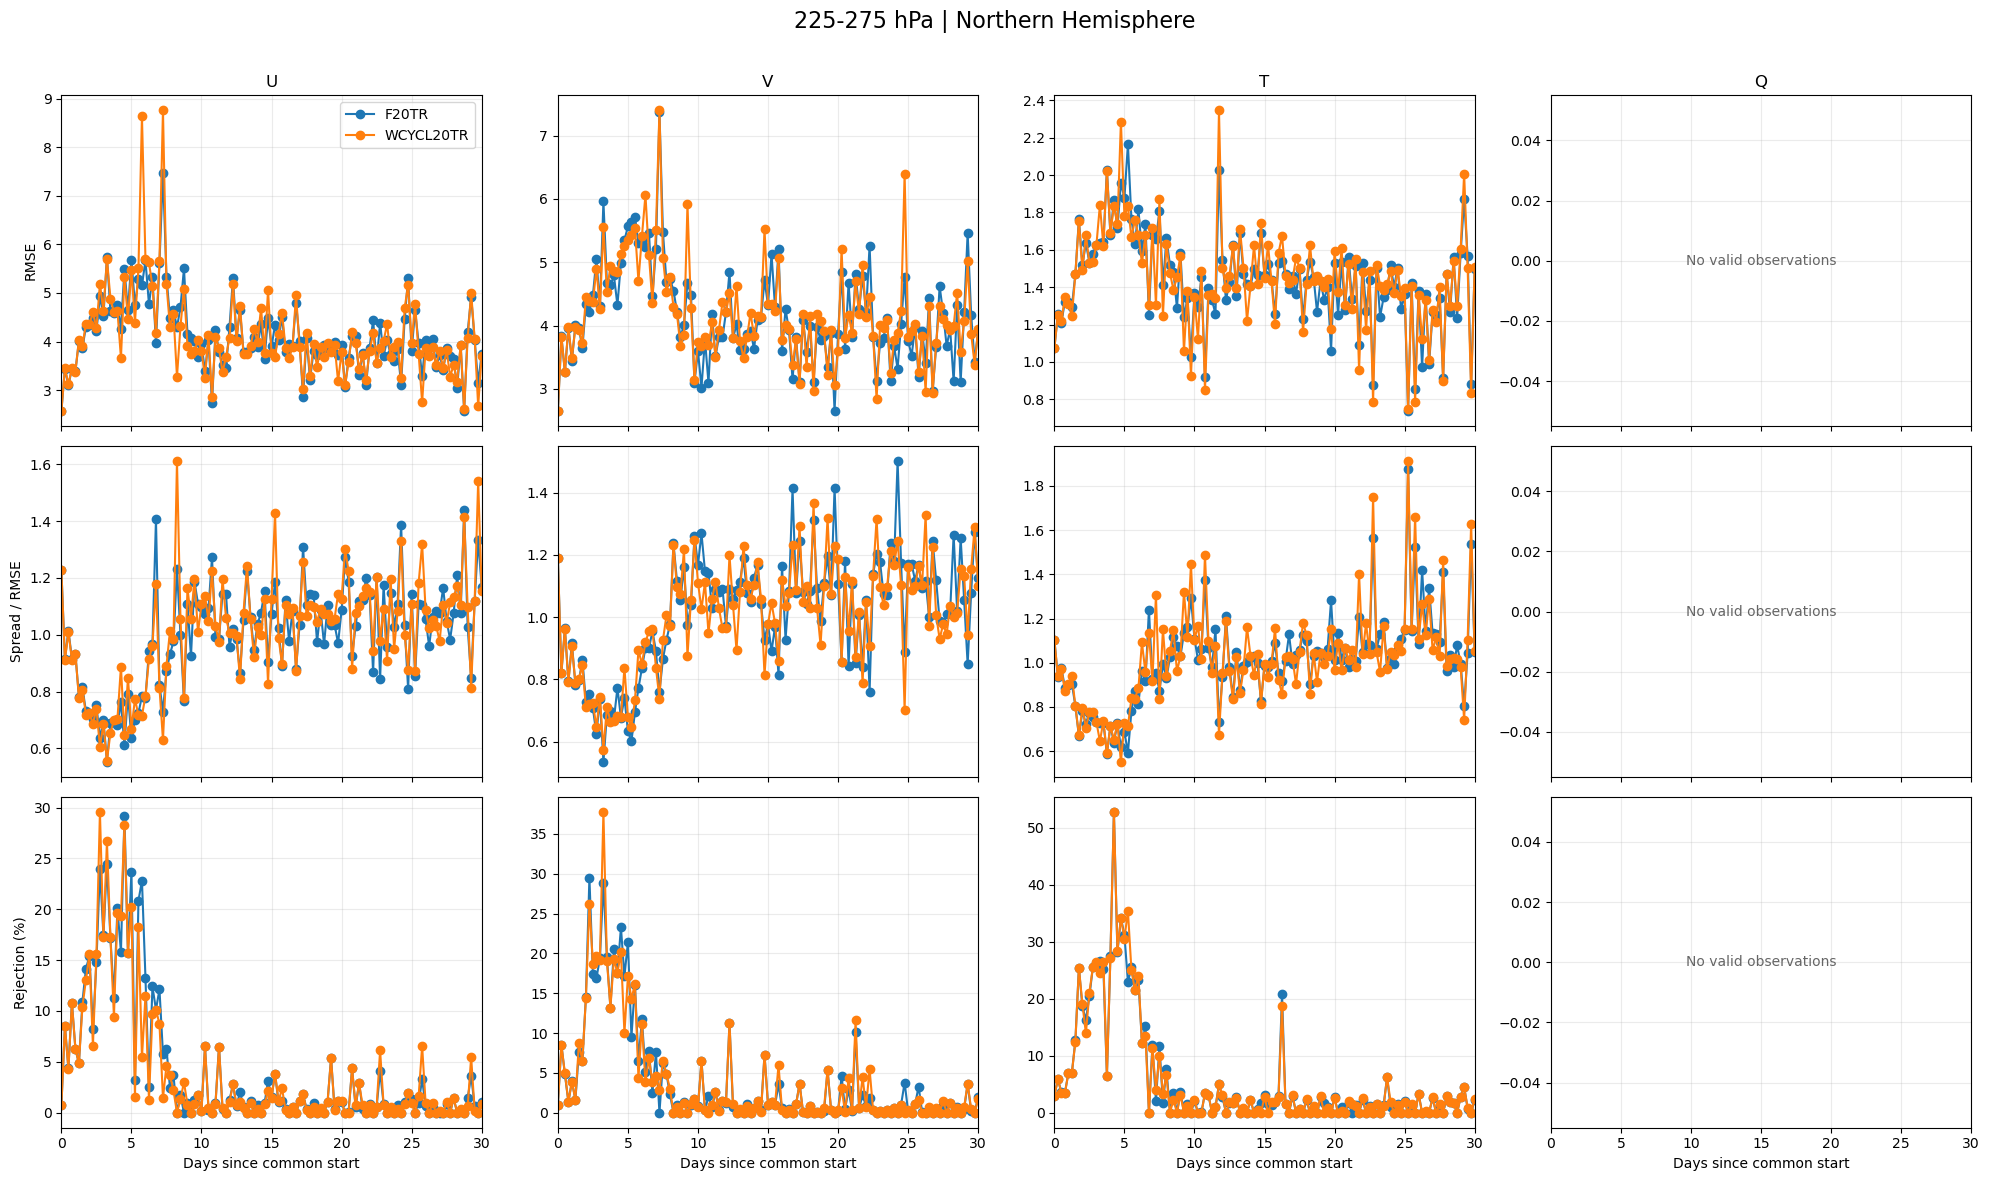

In [9]:
for level_label in PLOT_LEVELS:
    plot_level_comparison(level_label)
